In [1]:
#loading dfs
import os
import pandas as pd
from pathlib import Path
p2 = Path("..") / "1_Source_Files" / "df_final_web_data_pt_1.txt"
df2 = pd.read_csv(p2, sep=",", encoding="utf-8", engine="python") 

p3 = Path("..") / "1_Source_Files" / "df_final_web_data_pt_2.txt"
df3 = pd.read_csv(p3, sep=",", encoding="utf-8", engine="python") 

pC = Path("..") / "1.1_Clean_Files" / "df_final_experiment_clients_clean.csv"
dfC = pd.read_csv(pC, sep=",", encoding="utf-8", engine="python") 

pD = Path("..") / "1.1_Clean_Files" / "df1_demo_clean.csv"
dfD = pd.read_csv(pD, sep=",", encoding="utf-8", engine="python") 

In [2]:
#visual check 1.1_Clean_Files\df_final_experiment_clients_clean.csv
df2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [3]:
#visual check
df3.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [4]:
#merging vertically dfs into df4
df4 = pd.concat([df2, df3], ignore_index=True)
df4 = df4.drop_duplicates()
df4.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [5]:
#visual check 
df4.info()

<class 'pandas.DataFrame'>
Index: 744641 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     744641 non-null  int64
 1   visitor_id    744641 non-null  str  
 2   visit_id      744641 non-null  str  
 3   process_step  744641 non-null  str  
 4   date_time     744641 non-null  str  
dtypes: int64(1), str(4)
memory usage: 34.1 MB


In [6]:
#visual check
df4.isnull()

,client_id,visitor_id,visit_id,process_step,date_time
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
755400,False,False,False,False,False
755401,False,False,False,False,False
755402,False,False,False,False,False
755403,False,False,False,False,False


In [7]:
#cleaning and norilizing data
df4['client_id'] = df4['client_id'].astype(str).str.strip()
dfD['client_id'] = df4['client_id'].astype(str).str.strip()
df4['date_time'] = pd.to_datetime(df4['date_time'], errors='coerce')  

In [8]:
#cleaning and norilizing data
for text in ['visitor_id', 'visit_id', 'process_step']:
    if text in df4.columns:
        df4[text] = df4[text].astype(str).str.strip()

In [9]:
output_path = "../1.1_Clean_Files/df4_final_web_data_clean.csv"

df4.to_csv(output_path, index=False)


In [10]:
#visual check
df4 = df4.dropna(subset=['client_id', 'date_time'], how='any')

In [11]:
#visual check
print(df4.head())
print('rows:', len(df4))

  client_id            visitor_id                      visit_id process_step  \
0   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
1   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
2   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
3   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
4   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   

            date_time  
0 2017-04-17 15:27:07  
1 2017-04-17 15:26:51  
2 2017-04-17 15:19:22  
3 2017-04-17 15:19:13  
4 2017-04-17 15:18:04  
rows: 744641


In [12]:
#visual check for understanding
id_val = 9988021
date_val = "2017-04-17" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4[(df4['client_id'] == id_s) & (df4['date_time'].dt.date == target)]
print(result)

  client_id            visitor_id                      visit_id process_step  \
0   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
1   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
2   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
3   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
4   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
5   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
6   9988021  580560515_7732621733  781255054_21935453173_531117       step_1   
7   9988021  580560515_7732621733  781255054_21935453173_531117        start   

            date_time  
0 2017-04-17 15:27:07  
1 2017-04-17 15:26:51  
2 2017-04-17 15:19:22  
3 2017-04-17 15:19:13  
4 2017-04-17 15:18:04  
5 2017-04-17 15:17:15  
6 2017-04-17 15:17:01  
7 2017-04-17 15:16:22  


In [13]:
#visual check for understanding
id_val = 763412
#id_val = 6019349
date_val = "2017-06-06" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4[df4['client_id'] == id_s]
display(result)

,client_id,visitor_id,visit_id,process_step,date_time
343141,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
343322,763412,601952081_10457207388,275115855_33219234532_879732,confirm,2017-06-02 09:37:04
343323,763412,601952081_10457207388,275115855_33219234532_879732,step_3,2017-06-02 09:35:50
343324,763412,601952081_10457207388,275115855_33219234532_879732,step_2,2017-06-02 09:35:13
343325,763412,601952081_10457207388,275115855_33219234532_879732,step_1,2017-06-02 09:34:41
343326,763412,601952081_10457207388,275115855_33219234532_879732,start,2017-06-02 09:33:47


In [14]:
#visual check for understanding
id_val = 9988021
date_val = "2017-04-17" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result2 = df4[df4['process_step'] == "confirm" ]
display(result2)

,client_id,visitor_id,visit_id,process_step,date_time
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:03
14,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:01
15,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:28:52
24,1982004,618934751_10082078917,132494692_73738638511_70823,confirm,2017-04-17 12:02:42
...,...,...,...,...,...
755362,1462269,756274405_34153014475,903240226_7790404978_158729,confirm,2017-06-03 11:49:32
755368,9563467,358754208_29929976792,898272434_72817818195_285148,confirm,2017-06-04 10:21:23
755375,2443347,818414719_69544570654,148166449_67114410166_524360,confirm,2017-05-30 19:18:18
755376,9895983,473024645_56027518531,498981662_93503779869_272484,confirm,2017-06-15 19:55:09


In [15]:

dfC.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [16]:
client_id = 9988021
id_s = str(client_id)
target = pd.to_datetime(date_val).date()
result = dfC[dfC['client_id'] == id_s]
display(result)

,client_id,Variation


In [17]:
dfC['client_id'] = dfC['client_id'].astype(str)
df4C = df4.merge(dfC[['client_id','Variation']], on='client_id', how='left')

In [18]:
#visual check for understanding
id_val = 763412
#id_val = 6019349
date_val = "2017-06-06" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4C[df4C['client_id'] == id_s]
display(result)

,client_id,visitor_id,visit_id,process_step,date_time,Variation
341046,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00,NaN
341225,763412,601952081_10457207388,275115855_33219234532_879732,confirm,2017-06-02 09:37:04,NaN
341226,763412,601952081_10457207388,275115855_33219234532_879732,step_3,2017-06-02 09:35:50,NaN
341227,763412,601952081_10457207388,275115855_33219234532_879732,step_2,2017-06-02 09:35:13,NaN
341228,763412,601952081_10457207388,275115855_33219234532_879732,step_1,2017-06-02 09:34:41,NaN
341229,763412,601952081_10457207388,275115855_33219234532_879732,start,2017-06-02 09:33:47,NaN


In [19]:

dfC_agg = dfC.sort_values('client_id').groupby('client_id', as_index=False)['Variation'].first()

df4_with_variation = df4.merge(dfC_agg, on='client_id', how='inner')

# report counts
print("original df4 rows:", len(df4))
print("rows with assigned variation:", len(df4_with_variation))


original df4 rows: 744641
rows with assigned variation: 443897


In [20]:
output_path = "../1.1_Clean_Files/final_web_data_plus_experiments_clients.csv"

df4_with_variation.to_csv(output_path, index=False)


In [21]:
df5 = df4_with_variation

In [22]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 443897 entries, 0 to 443896
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     443897 non-null  str           
 1   visitor_id    443897 non-null  str           
 2   visit_id      443897 non-null  str           
 3   process_step  443897 non-null  str           
 4   date_time     443897 non-null  datetime64[us]
 5   Variation     443897 non-null  str           
dtypes: datetime64[us](1), str(5)
memory usage: 20.3 MB


In [23]:
df5.Variation.unique()

<StringArray>
['Test', 'Control', 'empty']
Length: 3, dtype: str

In [24]:
dfC.Variation.unique()

<StringArray>
['Test', 'Control', 'empty']
Length: 3, dtype: str

In [25]:
df5[df5['Variation'] == 'Test']

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test
...,...,...,...,...,...,...
413009,1574008,117364417_77840596075,528720790_71583064618_169151,confirm,2017-05-06 23:51:05,Test
413010,1574008,117364417_77840596075,528720790_71583064618_169151,step_3,2017-05-06 23:50:40,Test
413011,1574008,117364417_77840596075,528720790_71583064618_169151,step_2,2017-05-06 23:43:47,Test
413012,1574008,117364417_77840596075,528720790_71583064618_169151,step_1,2017-05-06 23:43:34,Test


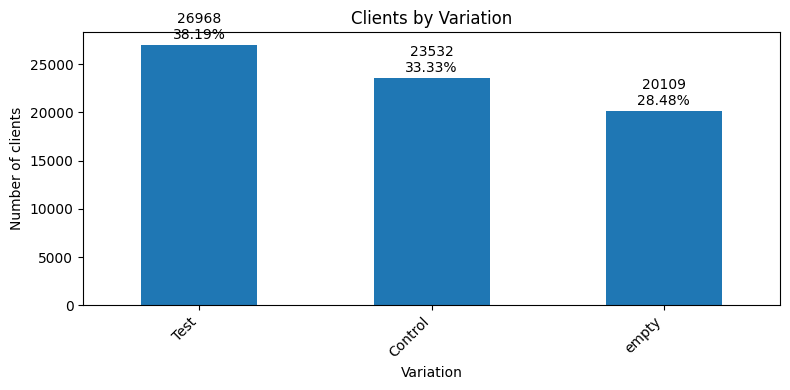

In [26]:
import matplotlib.pyplot as plt

# counts of unique clients by Variation
counts = df5.drop_duplicates('client_id')['Variation'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(8,4))
counts.plot(kind='bar', color='C0', ax=ax)

total = counts.sum()
for x, v in enumerate(counts):
    ax.text(x, v + total*0.005, f"{v}\n{v/total*100:.2f}%", ha='center', va='bottom')

ax.set_xlabel('Variation')
ax.set_ylabel('Number of clients')
ax.set_title('Clients by Variation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [27]:
df5.client_id.unique()

<StringArray>
['9988021', '8320017', '4033851', '1982004', '9294070', '9466803', '3170143',
 '6651403', '5887227', '2105948',
 ...
 '7598995',  '988886', '8973570', '9979751',  '104557', '4899619', '1672289',
 '1020453', '3897324', '9895983']
Length: 70609, dtype: str

In [28]:

dfC_agg = dfC.sort_values('client_id').groupby('client_id', as_index=False)['Variation'].first()

dfD_with_variation = dfD.merge(dfC_agg, on='client_id', how='inner')

# report counts
print("original df4 rows:", len(dfD))
print("rows with assigned variation:", len(dfD_with_variation))

original df4 rows: 70595
rows with assigned variation: 69049


In [29]:
df6=dfD_with_variation

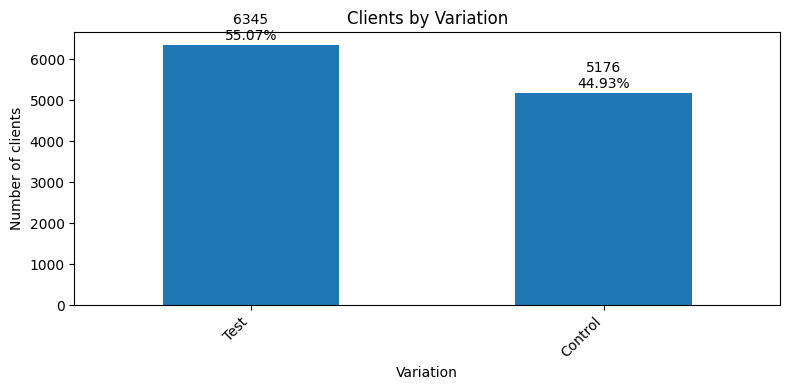

In [30]:
import matplotlib.pyplot as plt

# counts of unique clients by Variation
counts = df6.drop_duplicates('client_id')['Variation'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(8,4))
counts.plot(kind='bar', color='C0', ax=ax)

total = counts.sum()
for x, v in enumerate(counts):
    ax.text(x, v + total*0.005, f"{v}\n{v/total*100:.2f}%", ha='center', va='bottom')

ax.set_xlabel('Variation')
ax.set_ylabel('Number of clients')
ax.set_title('Clients by Variation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
df6.client_id.unique()

<StringArray>
['9988021', '8320017', '4033851', '1982004', '9294070', '9466803', '3170143',
 '6651403', '5887227', '2105948',
 ...
 '1273208', '5128721', '4358186', '2547675', '8079923', '9888495', '8914780',
 '6137908',  '292583', '6829681']
Length: 11521, dtype: str

In [32]:
dfC.client_id.unique()

<StringArray>
['9988021', '8320017', '4033851', '1982004', '9294070', '9466803', '3170143',
 '6651403', '5887227', '2105948',
 ...
 '5217934', '1020453', '9722009', '3897324',  '687702', '2443347', '8788427',
  '266828', '1266421', '9895983']
Length: 70609, dtype: str

In [33]:
output_path = "../1.1_Clean_Files/df1_demo_clean_plus_experiments_clients.csv"

df6.to_csv(output_path, index=False)

In [34]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 443897 entries, 0 to 443896
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     443897 non-null  str           
 1   visitor_id    443897 non-null  str           
 2   visit_id      443897 non-null  str           
 3   process_step  443897 non-null  str           
 4   date_time     443897 non-null  datetime64[us]
 5   Variation     443897 non-null  str           
dtypes: datetime64[us](1), str(5)
memory usage: 20.3 MB


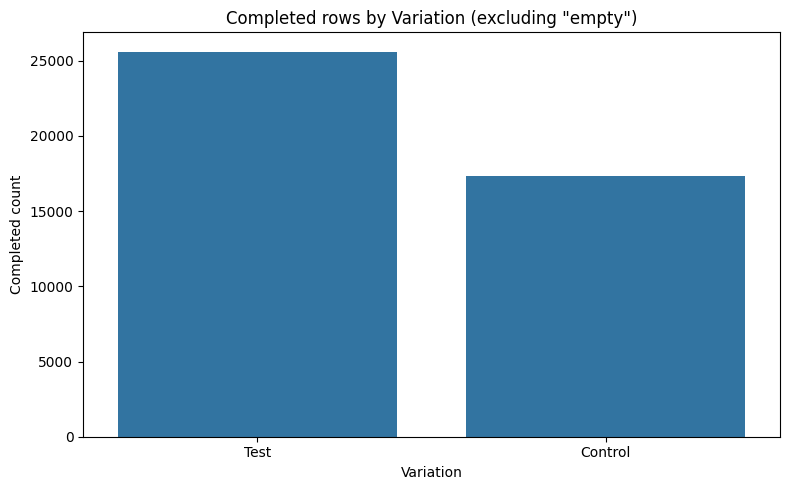

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_filtered = df5[df5['Variation'].str.lower() != 'empty']

completed = df_filtered[df_filtered['process_step'] == 'confirm']
counts = completed.groupby('Variation').size().reset_index(name='completed_count')

# plot
plt.figure(figsize=(8,5))
sns.barplot(data=counts, x='Variation', y='completed_count',
            order=counts.sort_values('completed_count', ascending=False)['Variation'])
plt.title('Completed rows by Variation (excluding "empty")')
plt.xlabel('Variation')
plt.ylabel('Completed count')
plt.tight_layout()
plt.show()



In [36]:
df6.info()

<class 'pandas.DataFrame'>
RangeIndex: 69049 entries, 0 to 69048
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   client_id             69049 non-null  str    
 1   client_tenure_years   69049 non-null  int64  
 2   client_tenure_months  69049 non-null  int64  
 3   client_age            69048 non-null  float64
 4   gender                69049 non-null  str    
 5   number_accounts       69049 non-null  int64  
 6   balance               69049 non-null  float64
 7   calls_6_months        69049 non-null  int64  
 8   logons_6_months       69049 non-null  int64  
 9   Variation             69049 non-null  str    
dtypes: float64(2), int64(5), str(3)
memory usage: 5.3 MB


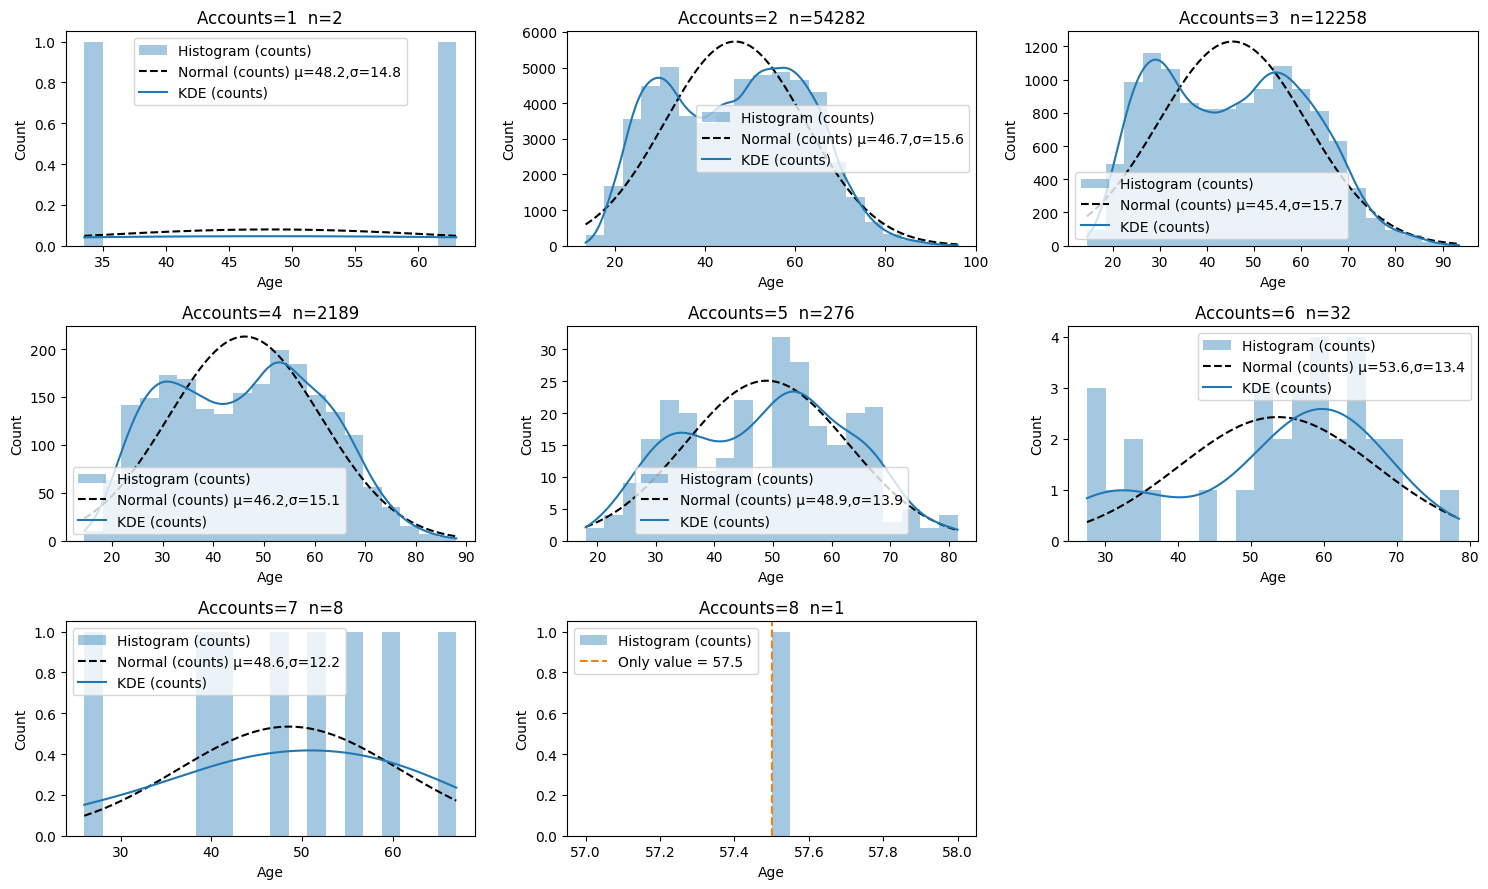

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, gaussian_kde

df00 = df6[df6['client_age'].notna()].copy()
groups = sorted(df00['number_accounts'].unique())
ncols = 3
nrows = int(np.ceil(len(groups)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*3))
axes = axes.ravel()

for i, acc in enumerate(groups):
    sub = df00[df00['number_accounts'] == acc]['client_age'].values
    ax = axes[i]
    if sub.size == 0:
        ax.set_visible(False)
        continue

    bins = 20
    counts, bin_edges, _ = ax.hist(sub, bins=bins, color='C0', alpha=0.4, label='Histogram (counts)')
    dx = bin_edges[1] - bin_edges[0]
    n = sub.size

    xs = np.linspace(sub.min(), sub.max(), 300)

    if n >= 2:
        mu_g, sigma_g = sub.mean(), sub.std(ddof=0)
        pdf_scaled = norm.pdf(xs, mu_g, sigma_g) * n * dx
        ax.plot(xs, pdf_scaled, color='k', linestyle='--', label=f'Normal (counts) μ={mu_g:.1f},σ={sigma_g:.1f}')

        kde = gaussian_kde(sub, bw_method='scott')
        kde_scaled = kde(xs) * n * dx
        ax.plot(xs, kde_scaled, color='C0', label='KDE (counts)')
    else:
        v = sub[0]
        ax.axvline(v, color='C1', linestyle='--', label=f'Only value = {v:.1f}')

    ax.set_title(f'Accounts={acc}  n={n}')
    ax.set_xlabel('Age'); ax.set_ylabel('Count')
    ax.legend()

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

age = 36.0
df = df00  # ваш DataFrame с client_age и number_accounts

# оценим μ и σ для каждой группы (используем ddof=0 как раньше)
stats = df.groupby('number_accounts')['client_age'].agg(['count','mean','std']).rename(columns={'count':'n','mean':'mu','std':'sigma'}).fillna(0)
total = stats['n'].sum()
stats['prior'] = stats['n'] / total

# для группы с sigma==0 (n<=1) задаём малую sigma, чтобы pdf работал:
stats['sigma'] = stats['sigma'].replace(0, 1.0)  # можно подобрать другое малое значение

# вычисляем likelihood = pdf(age | group)
stats['likelihood'] = norm.pdf(age, loc=stats['mu'], scale=stats['sigma'])

# постерiori ~ likelihood * prior
stats['posterior_unnorm'] = stats['likelihood'] * stats['prior']
stats['posterior'] = stats['posterior_unnorm'] / stats['posterior_unnorm'].sum()

# показать наиболее вероятные группы
result = stats[['n','mu','sigma','prior','likelihood','posterior']].sort_values('posterior', ascending=False)
display(result)


                     n         mu      sigma     prior     likelihood  \
number_accounts                                                         
2                54282  46.667717  15.592222  0.786149   2.024688e-02   
3                12258  45.436083  15.717623  0.177529   2.119624e-02   
4                 2189  46.200777  15.066861  0.031703   2.105486e-02   
5                  276  48.893116  13.965815  0.003997   1.865405e-02   
6                   32  53.640625  13.654867  0.000463   1.268255e-02   
7                    8  48.562500  13.088811  0.000116   1.922980e-02   
1                    2  48.250000  20.859650  0.000029   1.609589e-02   
8                    1  57.500000   1.000000  0.000014  1.677251e-101   

                     posterior  
number_accounts                 
2                 7.790783e-01  
3                 1.841813e-01  
4                 3.267121e-02  
5                 3.649634e-03  
6                 2.876893e-04  
7                 1.090516e-04  
1    

,n,mu,sigma,prior,likelihood,posterior
number_accounts,,,,,,
2,54282,46.667717,15.592222,0.786149,2.024688e-02,7.790783e-01
3,12258,45.436083,15.717623,0.177529,2.119624e-02,1.841813e-01
4,2189,46.200777,15.066861,0.031703,2.105486e-02,3.267121e-02
5,276,48.893116,13.965815,0.003997,1.865405e-02,3.649634e-03
6,32,53.640625,13.654867,0.000463,1.268255e-02,2.876893e-04
7,8,48.562500,13.088811,0.000116,1.922980e-02,1.090516e-04
1,2,48.250000,20.859650,0.000029,1.609589e-02,2.281981e-05
8,1,57.500000,1.000000,0.000014,1.677251e-101,1.188954e-104
